In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
plt.style.use("default")

In [13]:
df = pd.read_csv("../02_credit_default_model/data/credit_default.csv")

target_col = [c for c in df.columns if "default" in c.lower()][0]
df = df.rename(columns={target_col: "default"}).drop(columns=["ID"], errors="ignore")

print(df.shape, "default rate:", round(df["default"].mean(), 3))

(30000, 24) default rate: 0.221


In [14]:
df["utilization"] = (df["BILL_AMT1"] / df["LIMIT_BAL"]).clip(-1, 2)
df["log_payment"] = np.log1p(df["PAY_AMT1"])

features = ["LIMIT_BAL", "AGE", "utilization", "log_payment", "PAY_0"]
df[features].describe().round(2)

,LIMIT_BAL,AGE,utilization,log_payment,PAY_0
count,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,35.49,0.42,6.63,-0.02
std,129747.66,9.22,0.40,3.25,1.12
min,10000.00,21.00,-0.62,0.00,-2.00
25%,50000.00,28.00,0.02,6.91,-1.00
50%,140000.00,34.00,0.31,7.65,0.00
75%,240000.00,41.00,0.83,8.52,0.00
max,1000000.00,79.00,2.00,13.68,8.00


In [15]:
Z = StandardScaler().fit_transform(df[features])
print(Z.mean(axis=0).round(2), Z.std(axis=0).round(2))

[-0. -0. -0.  0. -0.] [1. 1. 1. 1. 1.]


2 0.242
3 0.269
4 0.249
5 0.263
6 0.256
7 0.262


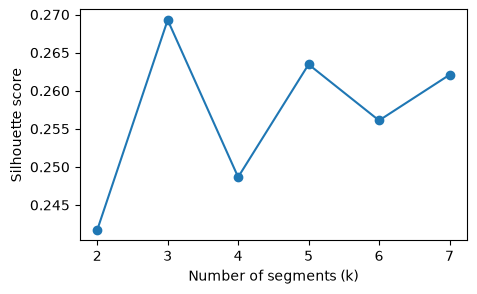

In [16]:
scores = {}
for k in range(2, 8):
    labels = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Z)
    scores[k] = silhouette_score(Z, labels, sample_size=5000, random_state=RANDOM_STATE)
    print(k, round(scores[k], 3))

plt.figure(figsize=(5, 3), facecolor="white")
plt.plot(list(scores), list(scores.values()), marker="o")
plt.xlabel("Number of segments (k)")
plt.ylabel("Silhouette score")
plt.show()

In [17]:
best_k = 4

km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
df["segment"] = km.fit_predict(Z)

profile = df.groupby("segment").agg(
    size=("segment", "size"),
    median_limit=("LIMIT_BAL", "median"),
    median_age=("AGE", "median"),
    median_utilization=("utilization", "median"),
    median_pay_status=("PAY_0", "median"),
    default_rate=("default", "mean"),
)
profile["share"] = profile["size"] / len(df)
profile.round(2)

,size,median_limit,median_age,median_utilization,median_pay_status,default_rate,share
segment,,,,,,,
0,9696,260000.0,35.0,0.03,-1.0,0.11,0.32
1,9652,80000.0,28.0,0.74,0.0,0.24,0.32
2,5426,80000.0,46.0,0.81,0.0,0.26,0.18
3,5226,140000.0,34.0,0.01,1.0,0.36,0.17


variance explained: [0.34 0.23]


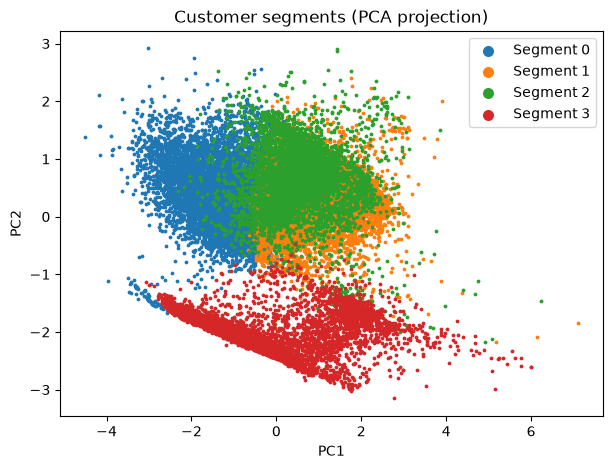

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Z)
print("variance explained:", pca.explained_variance_ratio_.round(2))

fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
for seg in sorted(df["segment"].unique()):
    mask = (df["segment"] == seg).to_numpy()
    ax.scatter(coords[mask, 0], coords[mask, 1], s=3, label=f"Segment {seg}")
ax.legend(markerscale=4)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Customer segments (PCA projection)")
plt.show()

In [19]:
labels_b = KMeans(n_clusters=best_k, n_init=10, random_state=7).fit_predict(Z)
print("agreement with a different seed:", round(adjusted_rand_score(df["segment"], labels_b), 3))

agreement with a different seed: 0.994


In [20]:
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE)
df["anomaly"] = iso.fit_predict(Z) == -1

print("flagged:", int(df["anomaly"].sum()))
print(df.groupby("anomaly")[["default"] + features].mean().round(2))

flagged: 600
         default  LIMIT_BAL    AGE  utilization  log_payment  PAY_0
anomaly                                                            
False       0.21  166636.04  35.29         0.42         6.71  -0.06
True        0.53  209050.00  45.03         0.65         2.55   1.98


Customers form a continuum more than tight clusters (silhouette 0.24 to 0.27), so I chose 4 segments for interpretability. The segments are stable across seeds (adjusted Rand index 0.994). Default rates range from 11% to 36% even though default was not used to build them. The "one month late" segment is the natural first target for outreach. Isolation Forest flagged 600 unusual customers who default at 53% vs 21%.